In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
ad = sc.read('../data/mtDNA_DSB_5k_clustered.h5ad')

In [3]:
ad

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Skipping 0.5: leiden_0.5 already exists.


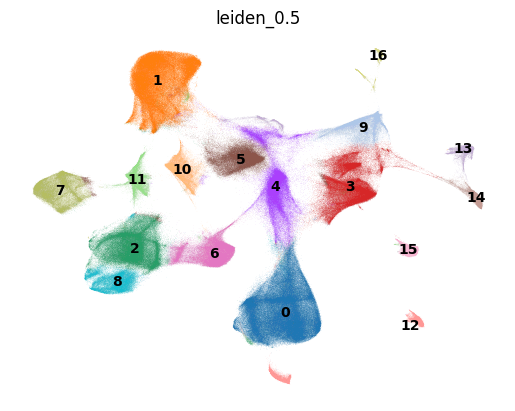

Skipping 1: leiden_1 already exists.


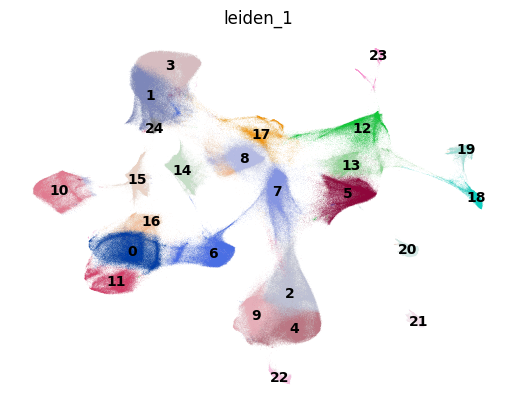

Clustering at resolution 1.5...


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


Done.


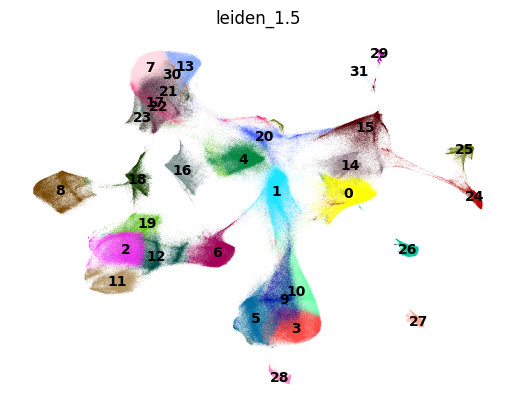

Skipping 2: leiden_2 already exists.


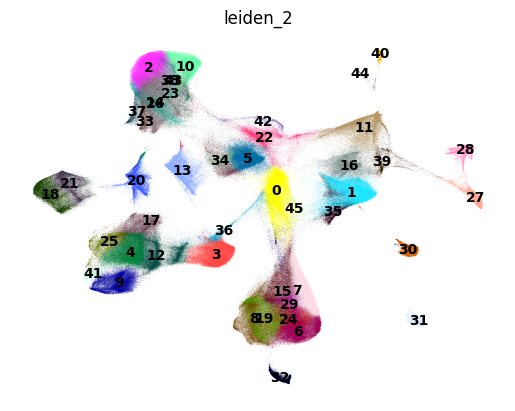

Clustering at resolution 2.1...
Done.


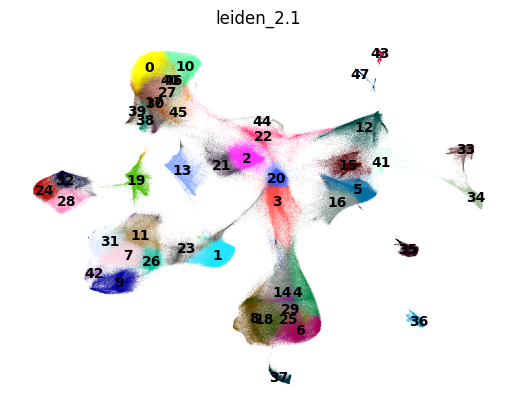

Clustering at resolution 2.3...
Done.


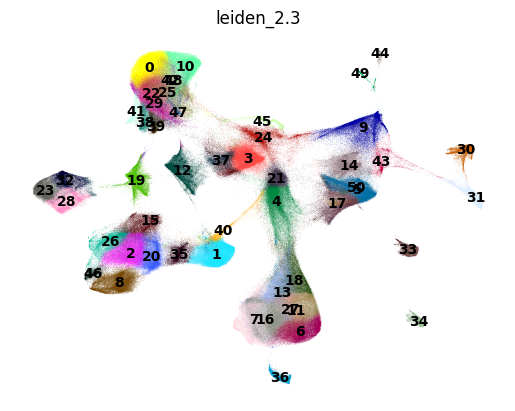

Clustering at resolution 2.5...
Done.


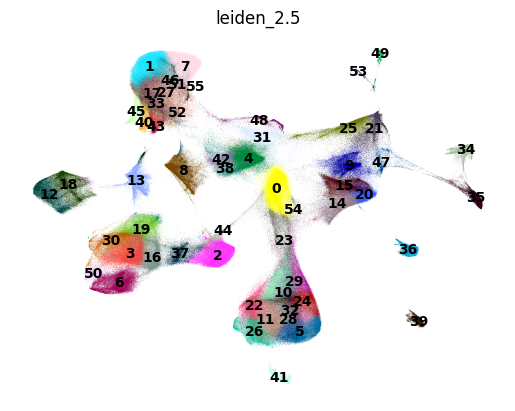

Clustering at resolution 3...
Done.


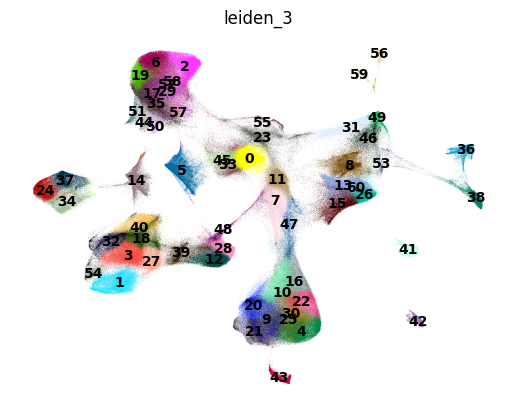

In [4]:
resolutions = [0.5, 1,1.5, 2, 2.1,2.3,2.5,3]

for resolution in resolutions:
    key = f'leiden_{resolution}'

    if key in ad.obs.columns:
        print(f"Skipping {resolution}: {key} already exists.")
    else:
        print(f"Clustering at resolution {resolution}...")
        sc.tl.leiden(ad, resolution=resolution, key_added=key)
        print("Done.")

    # plot UMAP
    sc.pl.umap(ad, color=key, legend_loc='on data', frameon=False)

In [6]:
ad.write('../data/mtDNA_DSB_5k_clustered_higher_res.h5ad')